In [6]:
import pandas as pd

feature_description = pd.DataFrame({
    "Feature": [
        "age",
        "workclass",
        "fnlwgt",
        "education",
        "education.num",
        "marital.status",
        "occupation",
        "relationship",
        "race",
        "sex",
        "capital.gain",
        "capital.loss",
        "hours.per.week",
        "native.country",
        "income (Target)"
    ],
    "Description": [
        "Age of the individual in years.",
        "Employment type (Private, Government, Self-employed, etc.).",
        "Final statistical weight assigned by the U.S. Census Bureau.",
        "Highest education level achieved.",
        "Numeric representation of education level.",
        "Marital status.",
        "Occupation or job type.",
        "Relationship within the family.",
        "Race category.",
        "Gender.",
        "Capital gains from investments.",
        "Capital losses from investments.",
        "Average working hours per week.",
        "Country of origin.",
        "Target variable: <=50K or >50K."
    ]
})

feature_description

,Feature,Description
0,age,Age of the individual in years.
1,workclass,"Employment type (Private, Government, Self-emp..."
2,fnlwgt,Final statistical weight assigned by the U.S. ...
3,education,Highest education level achieved.
4,education.num,Numeric representation of education level.
5,marital.status,Marital status.
6,occupation,Occupation or job type.
7,relationship,Relationship within the family.
8,race,Race category.
9,sex,Gender.


## 1. Import Libraries

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json, os
from datetime import datetime

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, learning_curve
)
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, AdaBoostClassifier,
    HistGradientBoostingClassifier, VotingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
warnings.filterwarnings('ignore')
np.random.seed(42)
print("Libraries loaded")

Libraries loaded


## 2. Load Dataset

In [27]:
df = pd.read_csv("adult.csv")
df = df.reset_index(drop=True)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Shape: (32561, 15)
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']


## 3. Initial Inspection

In [28]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [29]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [30]:
df.value_counts()

age  workclass  fnlwgt  education     education.num  marital.status      occupation         relationship   race                sex     capital.gain  capital.loss  hours.per.week  native.country  income
25   Private    195994  1st-4th       2              Never-married       Priv-house-serv    Not-in-family  White               Female  0             0             40              Guatemala       <=50K     3
90   Private    52386   Some-college  10             Never-married       Other-service      Not-in-family  Asian-Pac-Islander  Male    0             0             35              United-States   <=50K     2
19   Private    251579  Some-college  10             Never-married       Other-service      Own-child      White               Male    0             0             14              United-States   <=50K     2
25   Private    308144  Bachelors     13             Never-married       Craft-repair       Not-in-family  White               Male    0             0             40            

In [31]:
df.isnull().sum().sort_values(ascending=False)

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [32]:
print("Data types:")
print(df.dtypes)
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"Missing '?': {(df == '?').sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

Data types:
age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object

Missing values: 0
Missing '?': 4262
Duplicates: 24


## 4. Exploratory Data Analysis

In [12]:
os.makedirs('plots', exist_ok=True)
os.makedirs('reports', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('artifacts', exist_ok=True)

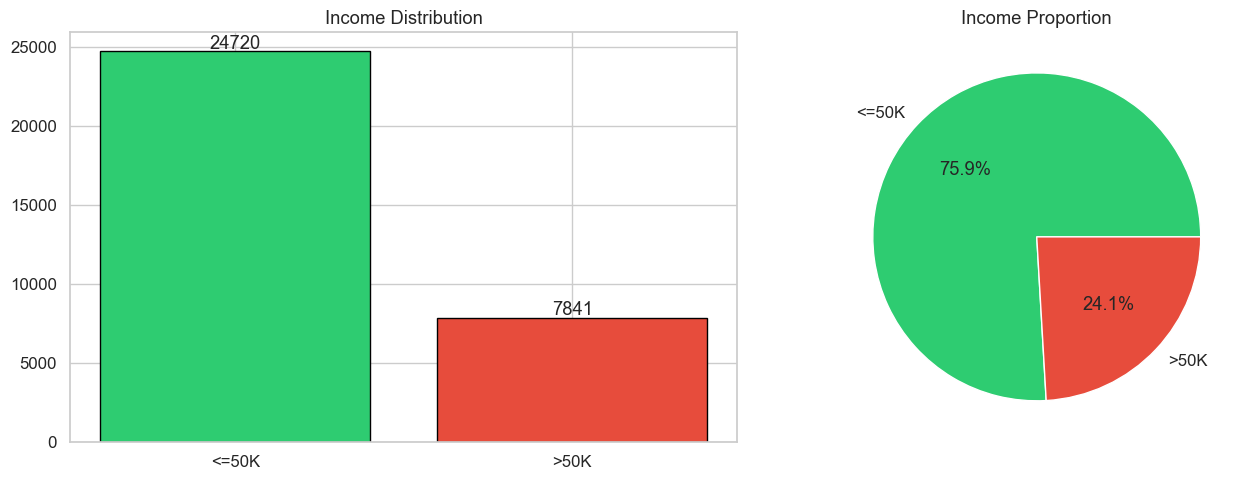

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df['income'].value_counts()
axes[0].bar(vc.index, vc.values, color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[0].set_title('Income Distribution')
for i,v in enumerate(vc.values):
    axes[0].text(i, v+200, str(v), ha='center')
axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'])
axes[1].set_title('Income Proportion')
plt.tight_layout()
plt.savefig('plots/target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
num_features = ['age','fnlwgt','education.num','capital.gain','capital.loss','hours.per.week']
cat_features = ['workclass','education','marital.status','occupation','relationship','race','sex','native.country']

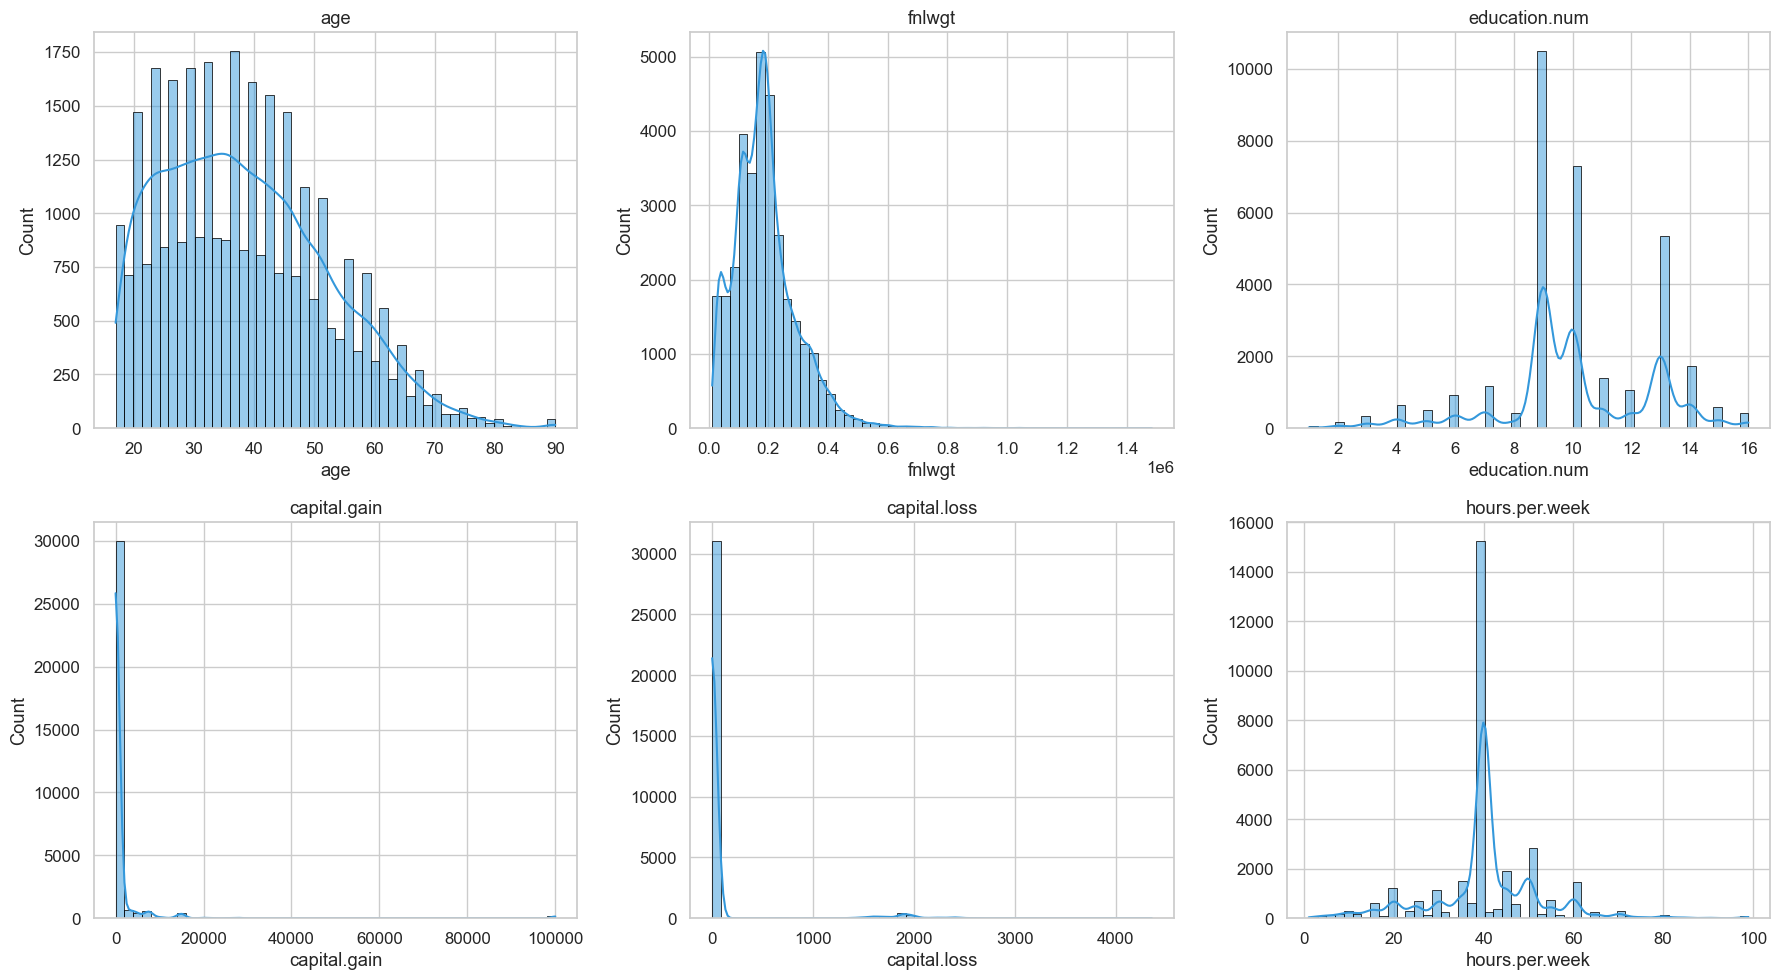

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(num_features):
    sns.histplot(df[col], bins=50, kde=True, ax=axes.flat[i], color='#3498db', edgecolor='black')
    axes.flat[i].set_title(col)
plt.tight_layout()
plt.savefig('plots/numerical_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

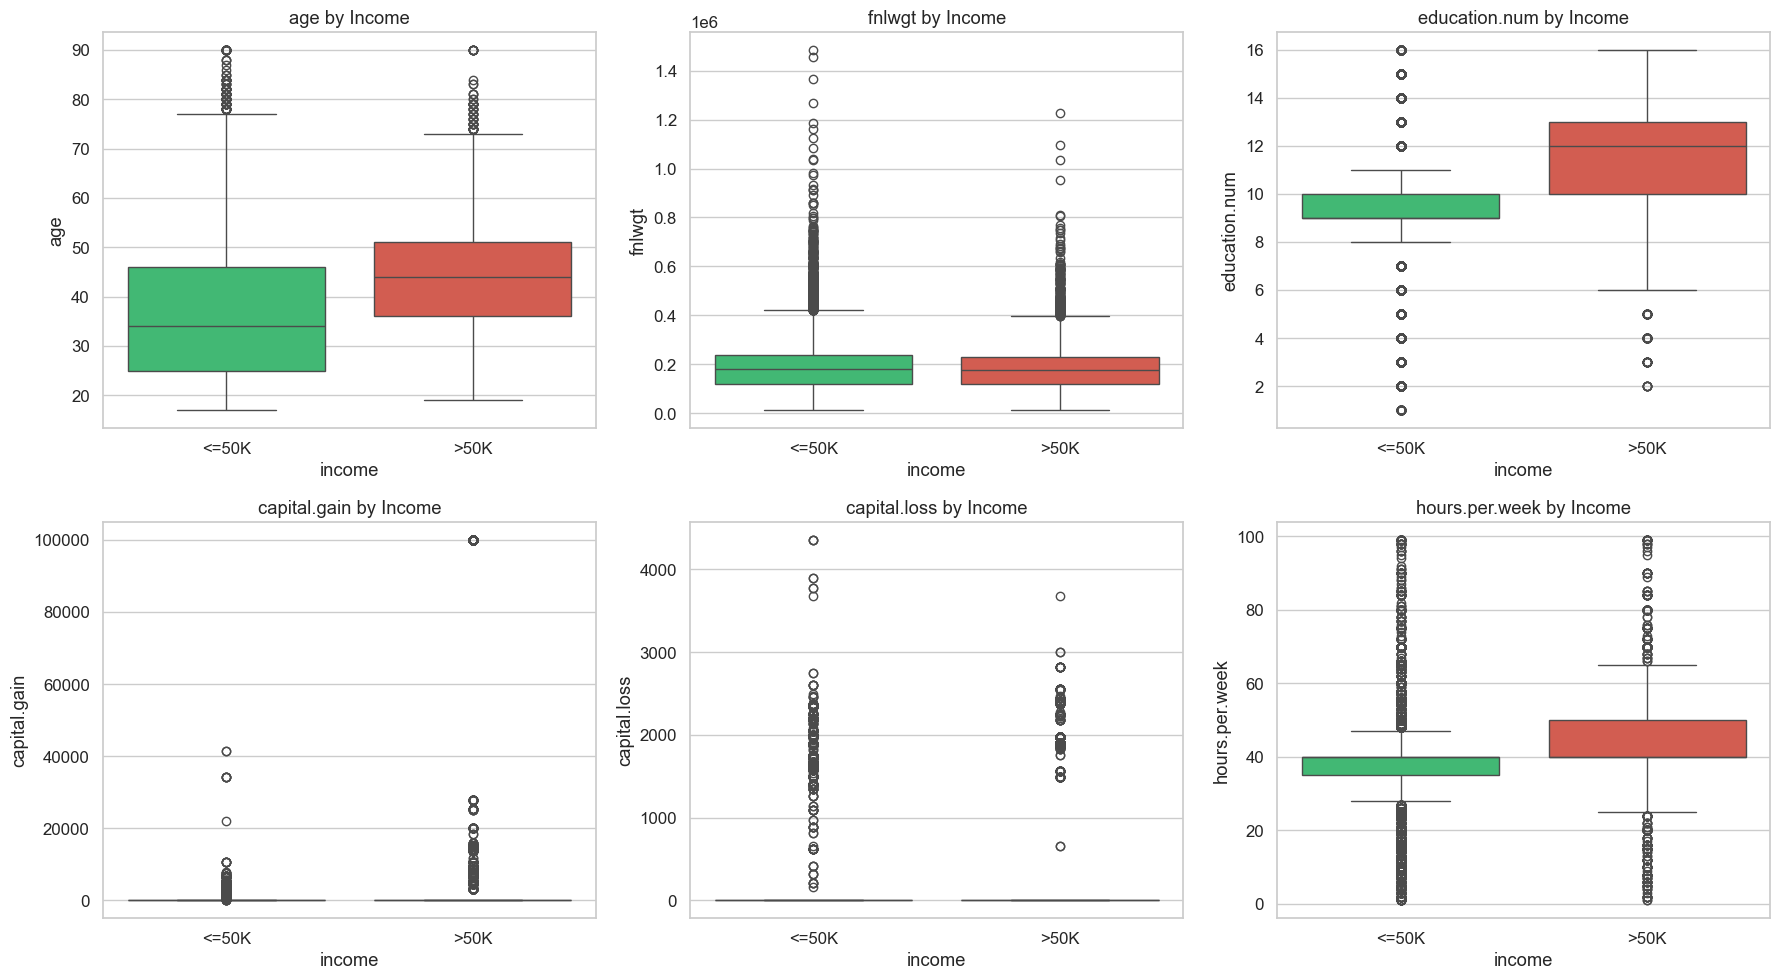

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(num_features):
    sns.boxplot(data=df, x='income', y=col, ax=axes.flat[i], palette={'<=50K':'#2ecc71','>50K':'#e74c3c'})
    axes.flat[i].set_title(f'{col} by Income')
plt.tight_layout()
plt.savefig('plots/boxplots_by_target.png', dpi=120, bbox_inches='tight')
plt.show()

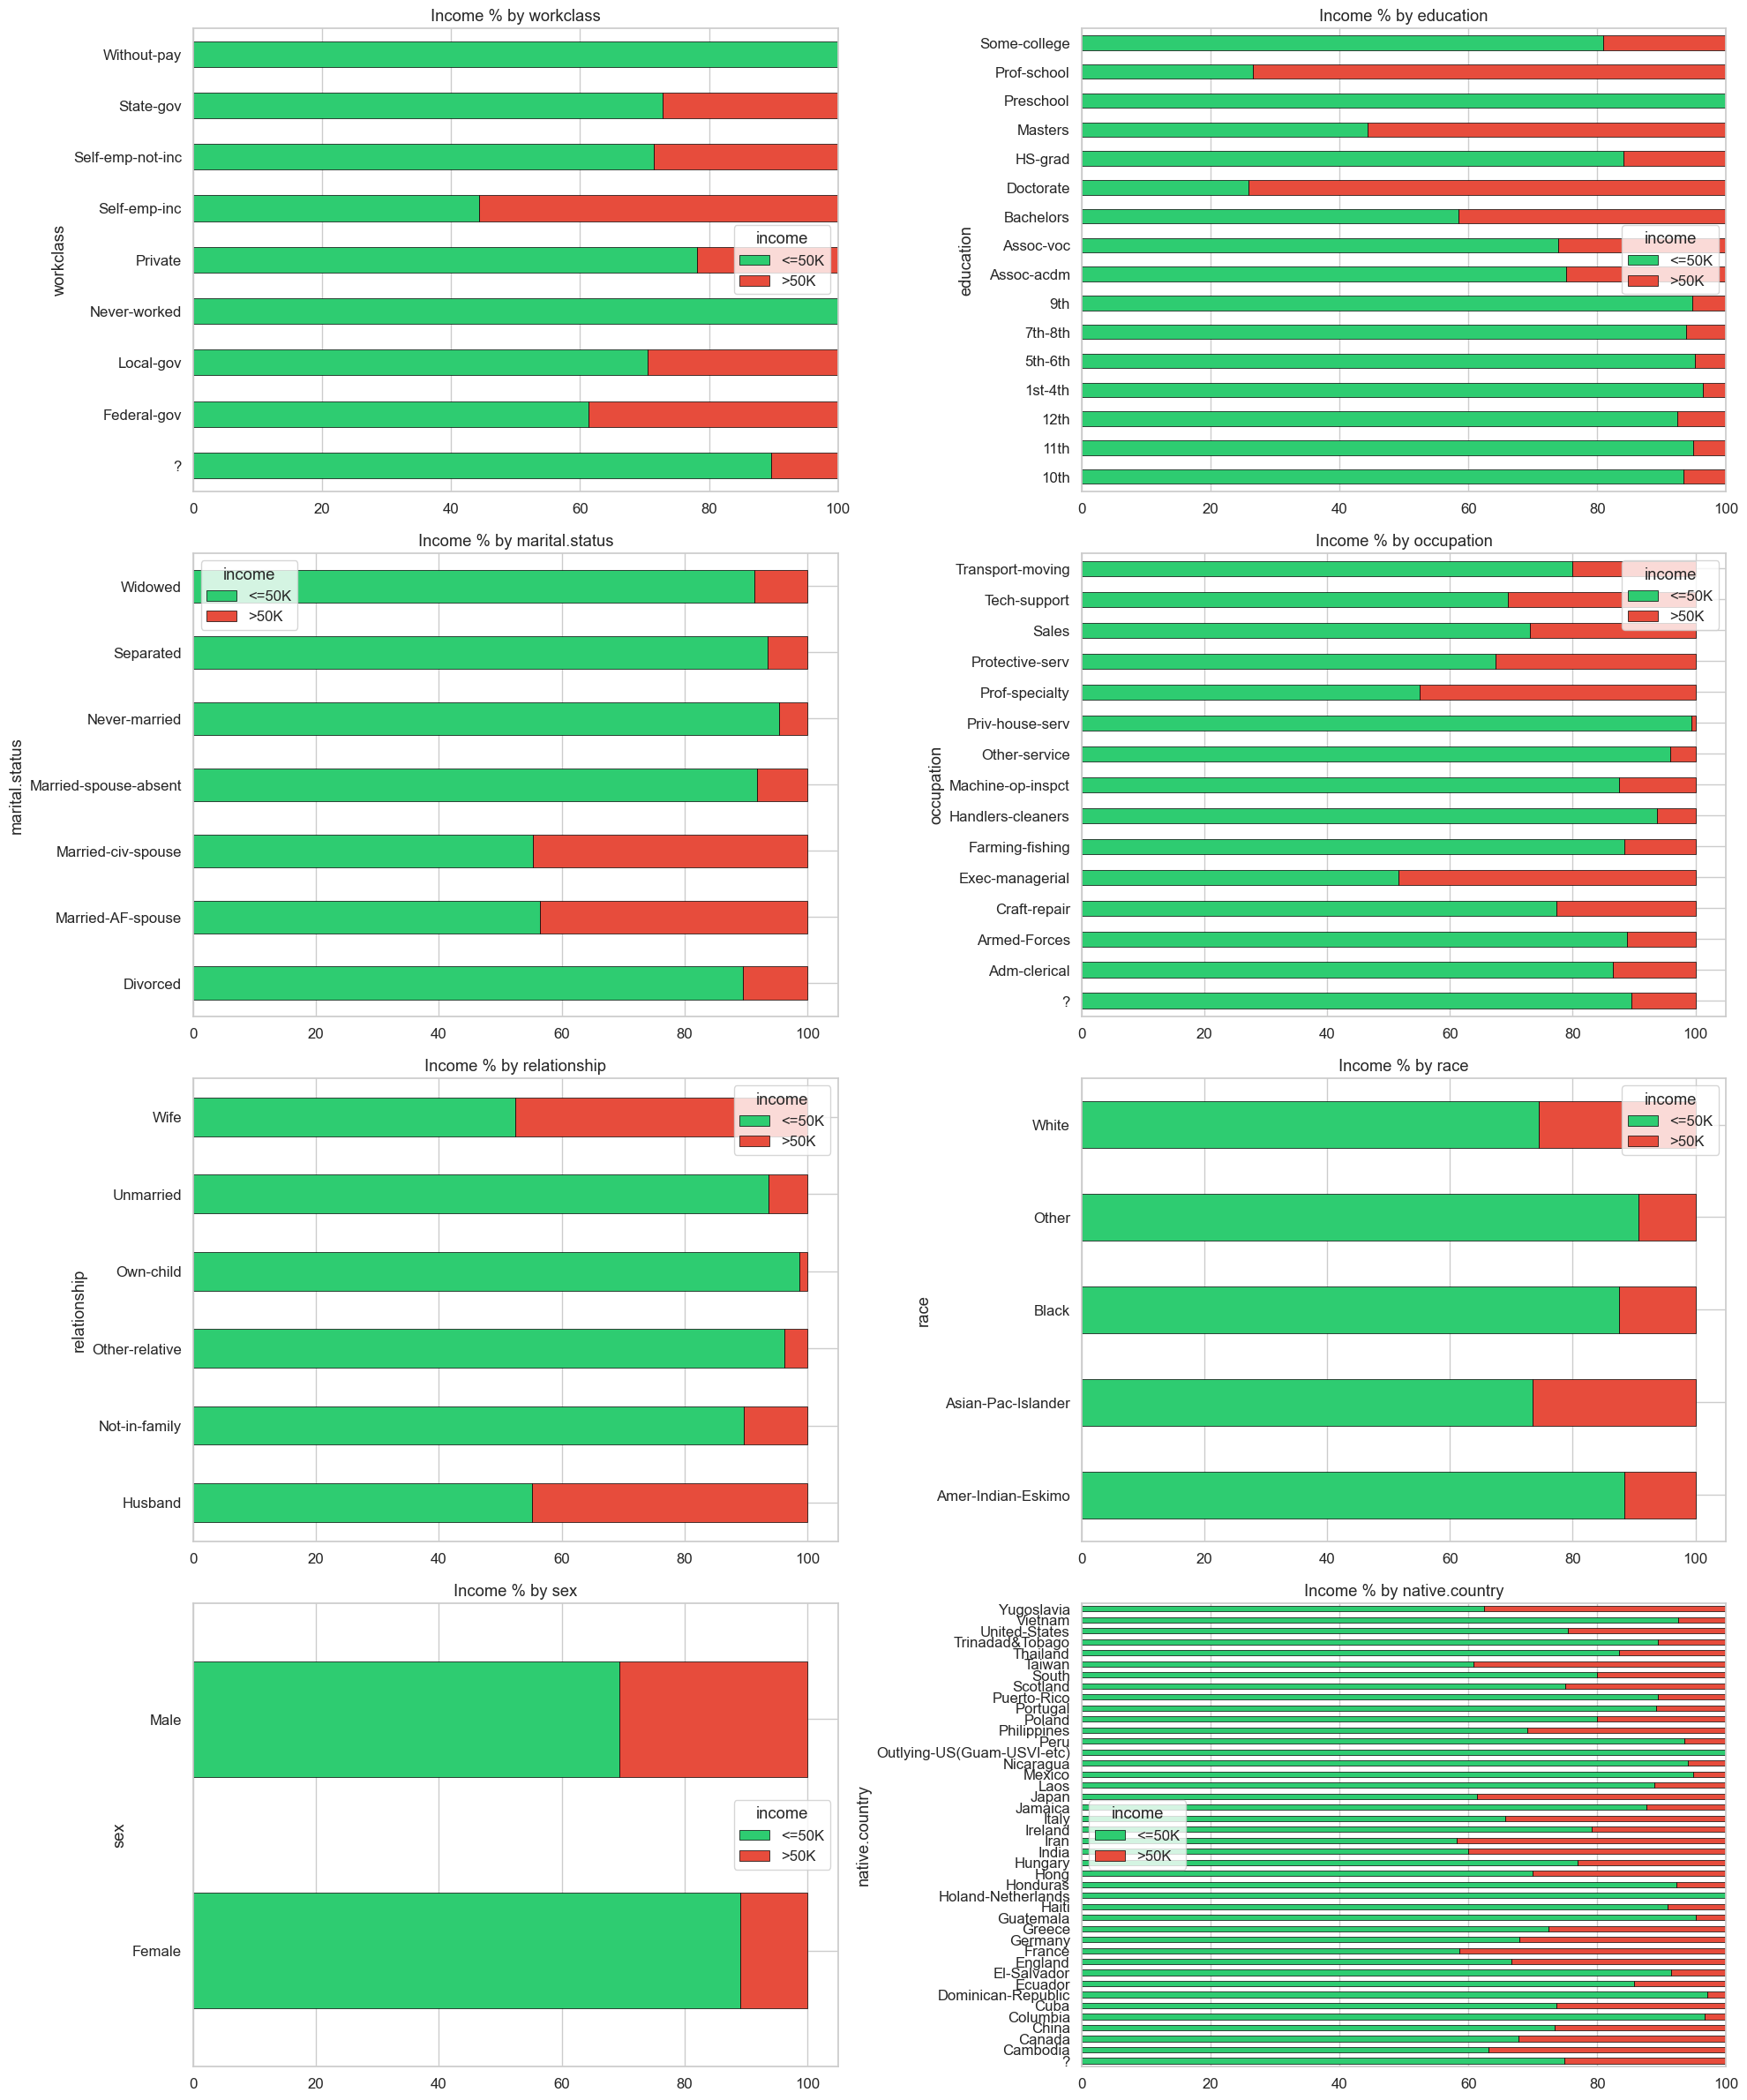

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(20, 24))
for i, col in enumerate(cat_features):
    ct = pd.crosstab(df[col], df['income'], normalize='index') * 100
    ct.plot(kind='barh', stacked=True, ax=axes.flat[i], color=['#2ecc71','#e74c3c'], edgecolor='black', linewidth=0.5)
    axes.flat[i].set_title(f'Income % by {col}')
plt.tight_layout()
plt.savefig('plots/income_by_category.png', dpi=120, bbox_inches='tight')
plt.show()

In [22]:
from sklearn.preprocessing import RobustScaler, OneHotEncoder, LabelEncoder

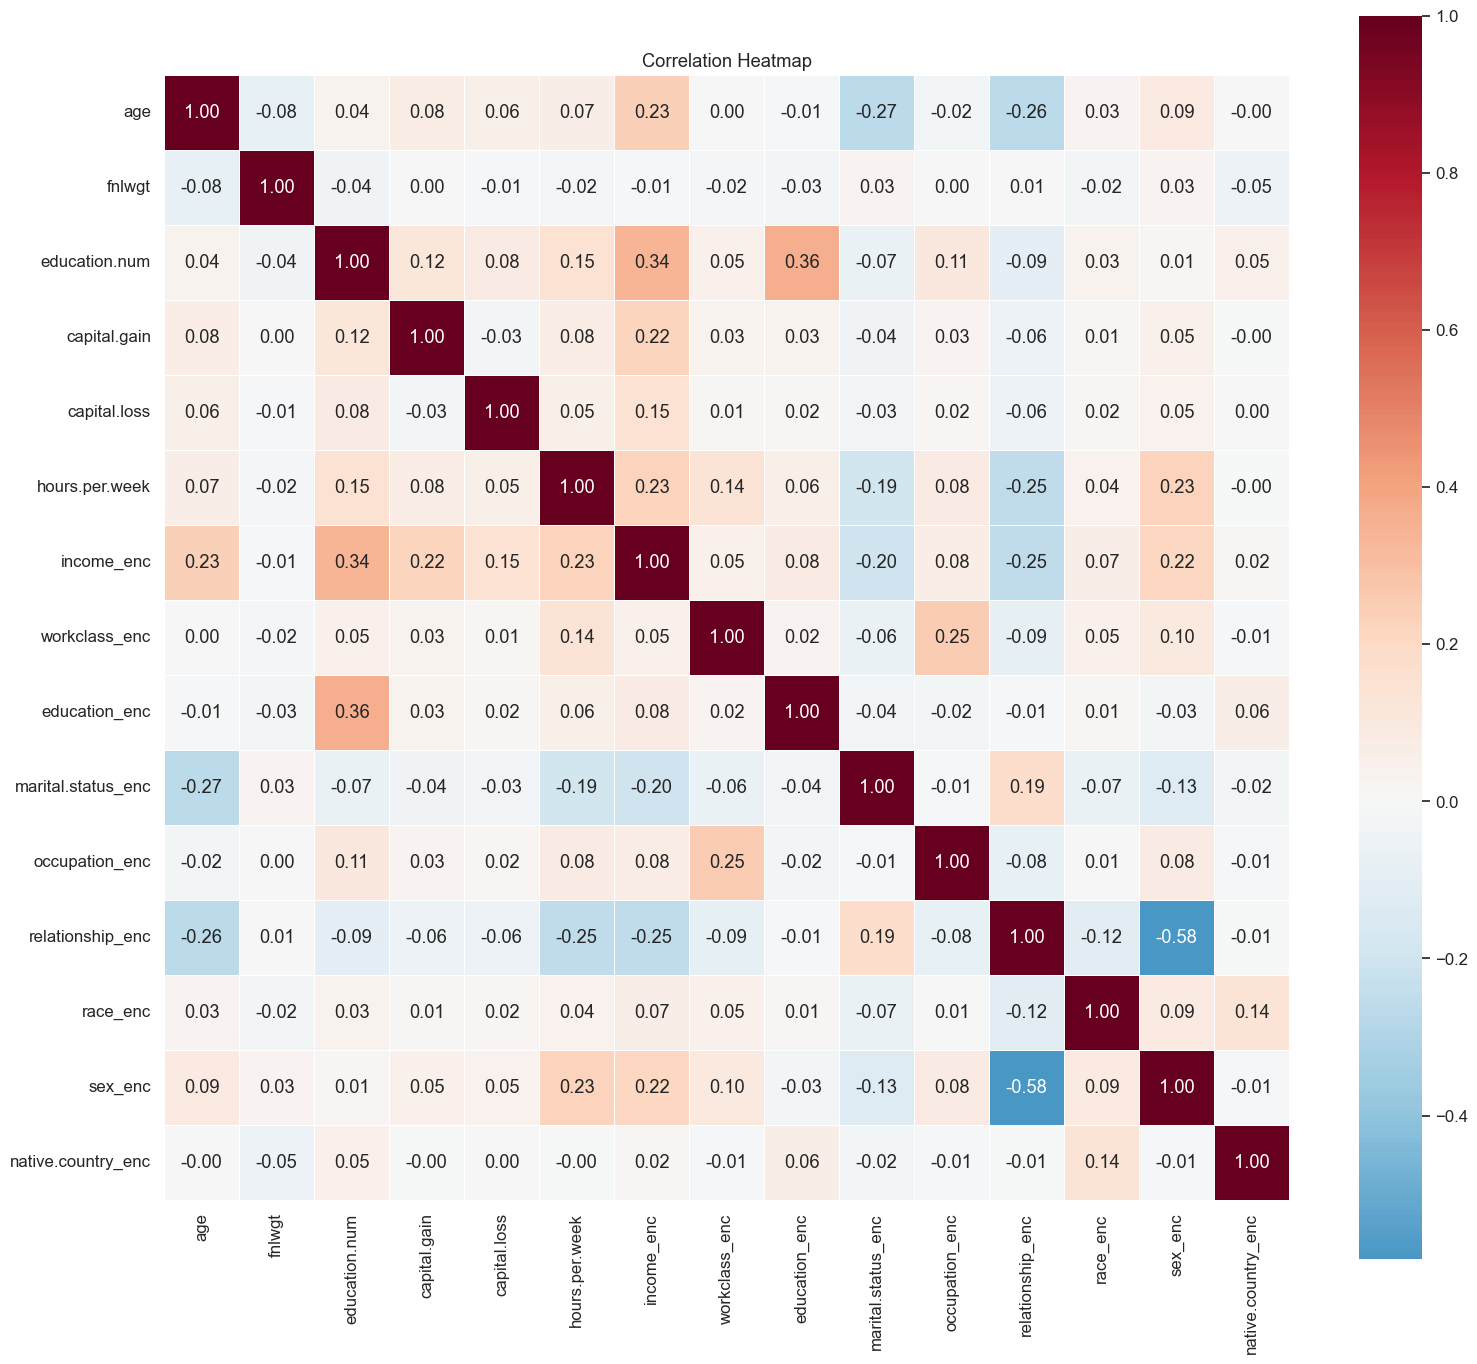

Top correlations with income:
education.num         0.335154
age                   0.234037
hours.per.week        0.229689
capital.gain          0.223329
sex_enc               0.215980
capital.loss          0.150526
education_enc         0.079317
occupation_enc        0.075468
race_enc              0.071846
workclass_enc         0.051604
native.country_enc    0.015840
fnlwgt               -0.009463
marital.status_enc   -0.199307
relationship_enc     -0.250918
Name: income_enc, dtype: float64


In [ ]:
df_corr = df.copy()
df_corr['income_enc'] = (df_corr['income'] == '>50K').astype(int)
for col in cat_features:
    df_corr[col+'_enc'] = LabelEncoder().fit_transform(df_corr[col].astype(str))
corr_cols = list(num_features) + ['income_enc'] + [c+'_enc' for c in cat_features]
corr_matrix = df_corr[corr_cols].corr()
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
target_corr = corr_matrix['income_enc'].drop('income_enc').sort_values(ascending=False)
print("Top correlations with income:")
print(target_corr)

## 5. Data Preprocessing

In [ ]:
df_clean = df.replace('?', np.nan).drop_duplicates()
num_features_raw = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_features_raw = df_clean.select_dtypes(include=['object']).columns.tolist()
cat_features_raw.remove('income')
print(f"After cleaning: {df_clean.shape}")

After cleaning: (32537, 15)


In [ ]:
df_clean[num_features_raw] = SimpleImputer(strategy='median').fit_transform(df_clean[num_features_raw])
df_clean[cat_features_raw] = SimpleImputer(strategy='most_frequent').fit_transform(df_clean[cat_features_raw])
for col in ['capital.gain', 'capital.loss']:
    df_clean[col + '_log'] = np.log1p(df_clean[col])
print(f"Missing after cleaning: {df_clean.isnull().sum().sum()}")

Missing after cleaning: 0


## 6. Feature Engineering

In [ ]:
df_fe = df_clean.copy()

df_fe['age_group'] = pd.cut(df_fe['age'], bins=[0,25,35,45,55,65,100],
    labels=['<25','25-34','35-44','45-54','55-64','65+'], right=False)

df_fe['hours_group'] = pd.cut(df_fe['hours.per.week'], bins=[0,20,30,40,50,60,100],
    labels=['<20','20-29','30-39','40-49','50-59','60+'], right=False)

df_fe['capital_total'] = df_fe['capital.gain'] + df_fe['capital.loss']
df_fe['has_capital'] = (df_fe['capital_total'] > 0).astype(int)

edu_map = {'Preschool':'Basic','1st-4th':'Basic','5th-6th':'Basic','7th-8th':'Basic',
    '9th':'Basic','10th':'High School','11th':'High School','12th':'High School',
    'HS-grad':'High School','Some-college':'College Prep','Assoc-voc':'Associate',
    'Assoc-acdm':'Associate','Bachelors':'Bachelors','Masters':'Masters',
    'Prof-school':'Doctorate','Doctorate':'Doctorate'}
df_fe['education_group'] = df_fe['education'].map(edu_map)

marital_map = {'Married-civ-spouse':'Married','Married-spouse-absent':'Married',
    'Married-AF-spouse':'Married','Never-married':'Not-Married','Divorced':'Not-Married',
    'Separated':'Not-Married','Widowed':'Not-Married'}
df_fe['marital_grouped'] = df_fe['marital.status'].map(marital_map)

df_fe['edu_age_ratio'] = df_fe['education.num'] / (df_fe['age'] + 1)

def group_country(c):
    us = ['United-States','Canada']
    ca = ['Mexico','Puerto-Rico','Cuba','Jamaica','Haiti','Dominican-Republic','El-Salvador','Guatemala','Nicaragua','Honduras','Trinadad&Tobago']
    sa = ['Columbia','Ecuador','Peru']
    as_ = ['China','India','Japan','Taiwan','Philippines','Vietnam','Thailand','Cambodia','Laos']
    eu = ['England','Germany','France','Italy','Greece','Poland','Portugal','Ireland','Scotland','Hungary','Yugoslavia','Holand-Netherlands']
    if c in us: return 'US/Canada'
    if c in ca: return 'Central America'
    if c in sa: return 'South America'
    if c in as_: return 'Asia'
    if c in eu: return 'Europe'
    return 'Other'

df_fe['region'] = df_fe['native.country'].apply(group_country)

print(f"Shape: {df_fe.shape}")
df_fe.head()

Shape: (32537, 25)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,...,capital.gain_log,capital.loss_log,age_group,hours_group,capital_total,has_capital,education_group,marital_grouped,edu_age_ratio,region
0,90.0,Private,77053.0,HS-grad,9.0,Widowed,Prof-specialty,Not-in-family,White,Female,...,0.0,8.379539,65+,40-49,4356.0,1,High School,Not-Married,0.098901,US/Canada
1,82.0,Private,132870.0,HS-grad,9.0,Widowed,Exec-managerial,Not-in-family,White,Female,...,0.0,8.379539,65+,<20,4356.0,1,High School,Not-Married,0.108434,US/Canada
2,66.0,Private,186061.0,Some-college,10.0,Widowed,Prof-specialty,Unmarried,Black,Female,...,0.0,8.379539,65+,40-49,4356.0,1,College Prep,Not-Married,0.149254,US/Canada
3,54.0,Private,140359.0,7th-8th,4.0,Divorced,Machine-op-inspct,Unmarried,White,Female,...,0.0,8.268988,45-54,40-49,3900.0,1,Basic,Not-Married,0.072727,US/Canada
4,41.0,Private,264663.0,Some-college,10.0,Separated,Prof-specialty,Own-child,White,Female,...,0.0,8.268988,35-44,40-49,3900.0,1,College Prep,Not-Married,0.238095,US/Canada


## 7. Train / Test Split

In [ ]:
target = (df_fe['income'] == '>50K').astype(int).values
feature_cols = [c for c in df_fe.columns if c != 'income']
X = df_fe[feature_cols].copy()
y = target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()

print(f"Train: {X_train.shape}  Test: {X_test.shape}")
print(f"Numerical: {len(num_cols)}  Categorical: {len(cat_cols)}")

Train: (26029, 24)  Test: (6508, 24)
Numerical: 11  Categorical: 13


## 8. Preprocessing Pipeline

In [ ]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=20))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

## 9. Define Models

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=1),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVC': SVC(probability=True, random_state=1),
    'Decision Tree': DecisionTreeClassifier(random_state=1),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=1),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=1),
    'AdaBoost': AdaBoostClassifier(random_state=1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=1),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(random_state=1),
    'XGBoost': xgb.XGBClassifier(eval_metric='logloss', random_state=1, use_label_encoder=False),
    'CatBoost': cb.CatBoostClassifier(verbose=0, random_state=1),
    'LightGBM': lgb.LGBMClassifier(random_state=1, verbose=-1),
}
print(f"{len(models)} models defined")

13 models defined


## 10. Train and Evaluate All Models

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
results = []

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    yp = pipe.predict(X_test)
    yp_proba = pipe.predict_proba(X_test)[:,1]
    cv_sc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, yp), 4),
        'Precision': round(precision_score(y_test, yp), 4),
        'Recall': round(recall_score(y_test, yp), 4),
        'F1 Score': round(f1_score(y_test, yp), 4),
        'ROC-AUC': round(roc_auc_score(y_test, yp_proba), 4),
        'PR-AUC': round(average_precision_score(y_test, yp_proba), 4),
        'CV ROC-AUC': round(cv_sc.mean(), 4)
    })
    print(f"{name:25s} F1={results[-1]['F1 Score']:.4f}  AUC={results[-1]['ROC-AUC']:.4f}")

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
print("\n--- Model Comparison ---")
print(results_df.to_string(index=False))

Logistic Regression       F1=0.6829  AUC=0.9159
KNN                       F1=0.6861  AUC=0.8839
SVC                       F1=0.4157  AUC=0.8714
Decision Tree             F1=0.6214  AUC=0.7531
Naive Bayes               F1=0.6630  AUC=0.8899
Random Forest             F1=0.6804  AUC=0.9081
Extra Trees               F1=0.6483  AUC=0.8801
AdaBoost                  F1=0.6554  AUC=0.9069
Gradient Boosting         F1=0.6856  AUC=0.9233
Hist Gradient Boosting    F1=0.7171  AUC=0.9281
XGBoost                   F1=0.7225  AUC=0.9270
CatBoost                  F1=0.7306  AUC=0.9319
LightGBM                  F1=0.7201  AUC=0.9291

--- Model Comparison ---
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  PR-AUC  CV ROC-AUC
              CatBoost    0.8791     0.7886  0.6805    0.7306   0.9319  0.8397      0.9266
               XGBoost    0.8743     0.7717  0.6792    0.7225   0.9270  0.8302      0.9230
              LightGBM    0.8740     0.7746  0.6728    0.7201   0.9291  0.834

## 11. Voting Classifier

In [ ]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr',  Pipeline([('preprocessor', preprocessor), ('model', LogisticRegression(max_iter=2000, random_state=1))])),
        ('rf',  Pipeline([('preprocessor', preprocessor), ('model', RandomForestClassifier(n_estimators=100, random_state=1))])),
        ('xgb', Pipeline([('preprocessor', preprocessor), ('model', xgb.XGBClassifier(eval_metric='logloss', random_state=1, use_label_encoder=False))])),
        ('lgbm', Pipeline([('preprocessor', preprocessor), ('model', lgb.LGBMClassifier(random_state=1, verbose=-1))])),
        ('et',  Pipeline([('preprocessor', preprocessor), ('model', ExtraTreesClassifier(n_estimators=100, random_state=1))])),
    ],
    voting='soft',
    n_jobs=-1
)

voting_clf.fit(X_train, y_train)
y_pred_v = voting_clf.predict(X_test)
y_proba_v = voting_clf.predict_proba(X_test)[:,1]

print(f"VotingClassifier Accuracy:  {accuracy_score(y_test, y_pred_v):.4f}")
print(f"VotingClassifier Precision: {precision_score(y_test, y_pred_v):.4f}")
print(f"VotingClassifier Recall:    {recall_score(y_test, y_pred_v):.4f}")
print(f"VotingClassifier F1:        {f1_score(y_test, y_pred_v):.4f}")
print(f"VotingClassifier ROC-AUC:   {roc_auc_score(y_test, y_proba_v):.4f}")
print(f"VotingClassifier PR-AUC:    {average_precision_score(y_test, y_proba_v):.4f}")

results.append({
    'Model': 'Voting Classifier',
    'Accuracy': round(accuracy_score(y_test, y_pred_v), 4),
    'Precision': round(precision_score(y_test, y_pred_v), 4),
    'Recall': round(recall_score(y_test, y_pred_v), 4),
    'F1 Score': round(f1_score(y_test, y_pred_v), 4),
    'ROC-AUC': round(roc_auc_score(y_test, y_proba_v), 4),
    'PR-AUC': round(average_precision_score(y_test, y_proba_v), 4),
    'CV ROC-AUC': '-'
})

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
print("\n--- Updated Model Comparison ---")
print(results_df.to_string(index=False))

VotingClassifier Accuracy:  0.8705
VotingClassifier Precision: 0.7671
VotingClassifier Recall:    0.6639
VotingClassifier F1:        0.7118
VotingClassifier ROC-AUC:   0.9230
VotingClassifier PR-AUC:    0.8215

--- Updated Model Comparison ---
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  PR-AUC CV ROC-AUC
              CatBoost    0.8791     0.7886  0.6805    0.7306   0.9319  0.8397     0.9266
               XGBoost    0.8743     0.7717  0.6792    0.7225   0.9270  0.8302      0.923
              LightGBM    0.8740     0.7746  0.6728    0.7201   0.9291  0.8340     0.9255
Hist Gradient Boosting    0.8731     0.7744  0.6677    0.7171   0.9281  0.8317     0.9244
     Voting Classifier    0.8705     0.7671  0.6639    0.7118   0.9230  0.8215          -
                   KNN    0.8526     0.7048  0.6684    0.6861   0.8839  0.7238     0.8823
     Gradient Boosting    0.8654     0.7841  0.6091    0.6856   0.9233  0.8202     0.9201
   Logistic Regression    0.8600    

## 12. Hyperparameter Tuning
Tuning the top 3 models using GridSearchCV with 3-fold cross-validation.

In [ ]:
top3 = results_df.head(3)['Model'].tolist()
print(f"Tuning: {top3}")

Tuning: ['CatBoost', 'XGBoost', 'LightGBM']


In [ ]:
param_grids = {
    'Random Forest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [10, 20, None],
        'model__min_samples_split': [2, 5]
    },
    'XGBoost': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [4, 6, 8],
        'model__learning_rate': [0.05, 0.1],
        'model__subsample': [0.8, 1.0]
    },
    'LightGBM': {
        'model__n_estimators': [100, 200],
        'model__num_leaves': [31, 50],
        'model__max_depth': [6, 8, -1],
        'model__learning_rate': [0.05, 0.1]
    },
    'Gradient Boosting': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [3, 5],
        'model__learning_rate': [0.05, 0.1]
    },
    'Extra Trees': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [10, 20, None],
        'model__min_samples_split': [2, 5]
    },
    'Hist Gradient Boosting': {
        'model__max_iter': [100, 200],
        'model__max_depth': [5, 10, None],
        'model__learning_rate': [0.05, 0.1]
    },
    'CatBoost': {
        'model__iterations': [100, 200],
        'model__learning_rate': [0.03, 0.1],
        'model__depth': [4, 6]
    }
}

tuned = {}
for name in top3:
    if name not in param_grids:
        print(f"Skipping {name}")
        continue
    pipe = Pipeline([('preprocessor', preprocessor), ('model', models[name])])
    grid = GridSearchCV(pipe, param_grids[name], cv=3, scoring='roc_auc', n_jobs=-1, verbose=0)
    grid.fit(X_train, y_train)
    yp = grid.predict(X_test)
    yp_proba = grid.predict_proba(X_test)[:,1]
    tuned[name] = {
        'pipeline': grid.best_estimator_,
        'results': {
            'Model': name+' (Tuned)',
            'Accuracy': round(accuracy_score(y_test, yp), 4),
            'Precision': round(precision_score(y_test, yp), 4),
            'Recall': round(recall_score(y_test, yp), 4),
            'F1 Score': round(f1_score(y_test, yp), 4),
            'ROC-AUC': round(roc_auc_score(y_test, yp_proba), 4),
            'PR-AUC': round(average_precision_score(y_test, yp_proba), 4)
        }
    }
    print(f"{name}: params={grid.best_params_}")
    print(f"  F1={tuned[name]['results']['F1 Score']:.4f}  AUC={tuned[name]['results']['ROC-AUC']:.4f}")

CatBoost: params={'model__depth': 6, 'model__iterations': 200, 'model__learning_rate': 0.1}
  F1=0.7148  AUC=0.9314
XGBoost: params={'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 200, 'model__subsample': 1.0}
  F1=0.7181  AUC=0.9305
LightGBM: params={'model__learning_rate': 0.05, 'model__max_depth': -1, 'model__n_estimators': 200, 'model__num_leaves': 31}
  F1=0.7278  AUC=0.9296


In [ ]:
tuned_df = pd.DataFrame([v['results'] for v in tuned.values()])
print("--- Tuned Model Results ---")
print(tuned_df.to_string(index=False))

for tname in top3:
    if tname in tuned:
        results.append(tuned[tname]['results'])
results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)

--- Tuned Model Results ---
           Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  PR-AUC
CatBoost (Tuned)    0.8738     0.7849  0.6562    0.7148   0.9314  0.8379
 XGBoost (Tuned)    0.8748     0.7846  0.6620    0.7181   0.9305  0.8377
LightGBM (Tuned)    0.8778     0.7857  0.6779    0.7278   0.9296  0.8352


## 13. Select Best Model

In [ ]:
if tuned:
    best_name = max(tuned, key=lambda n: tuned[n]['results']['F1 Score'])
    best_pipe = tuned[best_name]['pipeline']
    best_res = tuned[best_name]['results']
    print(f"Best tuned model: {best_name}")
else:
    best_name = results_df.iloc[0]['Model']
    best_pipe = Pipeline([('preprocessor', preprocessor), ('model', models[best_name])])
    best_pipe.fit(X_train, y_train)
    best_res = results_df.iloc[0].to_dict()
    print(f"Best model: {best_name}")

y_pred = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)[:,1]
print(f"F1={best_res.get('F1 Score', 0):.4f}  ROC-AUC={best_res.get('ROC-AUC', 0):.4f}")

Best tuned model: LightGBM
F1=0.7278  ROC-AUC=0.9296


## 14. Model Evaluation

In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92      4940
        >50K       0.79      0.68      0.73      1568

    accuracy                           0.88      6508
   macro avg       0.84      0.81      0.82      6508
weighted avg       0.87      0.88      0.87      6508



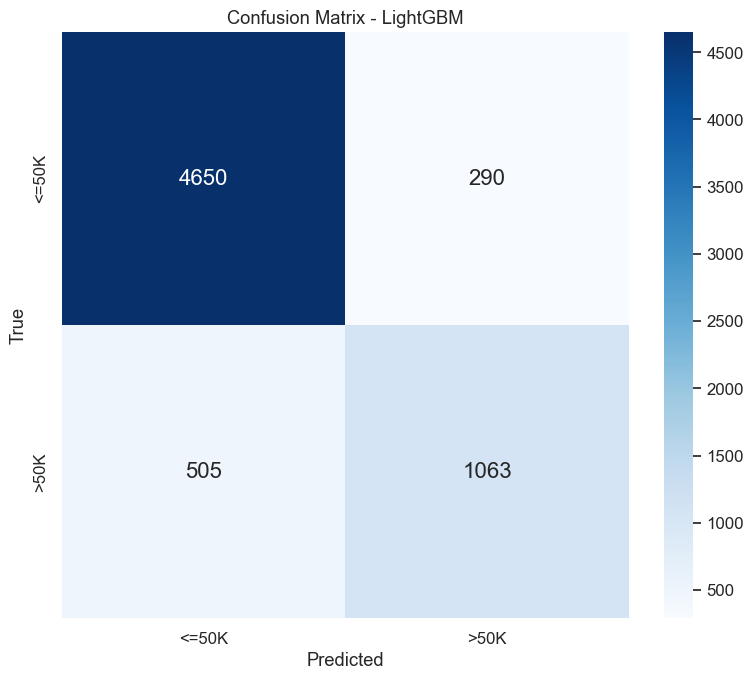

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['<=50K','>50K'], yticklabels=['<=50K','>50K'], annot_kws={'fontsize':16})
plt.title(f'Confusion Matrix - {best_name}')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.savefig('plots/confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

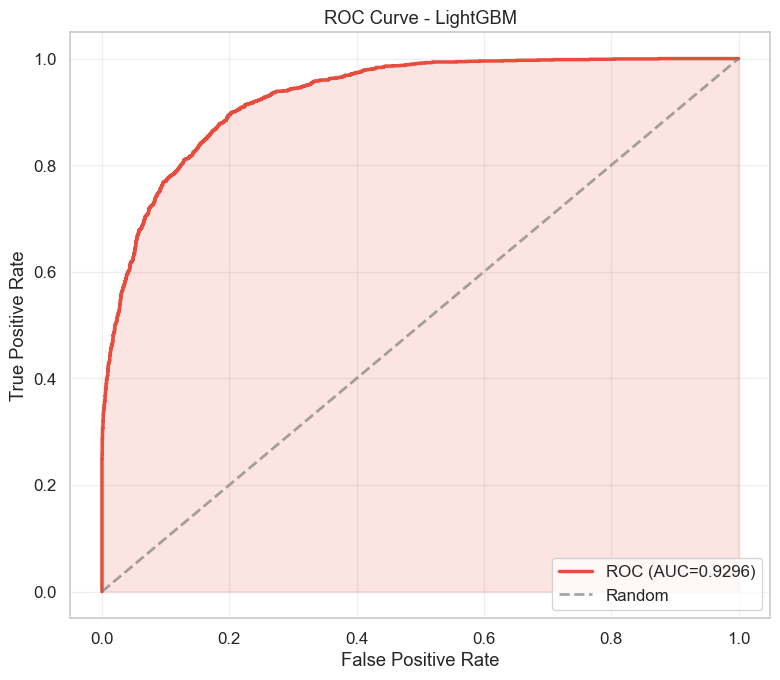

ROC-AUC: 0.9296


In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_val = roc_auc_score(y_test, y_proba)
plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, color='#e74c3c', lw=2.5, label=f'ROC (AUC={auc_val:.4f})')
plt.plot([0,1],[0,1], color='gray', ls='--', lw=2, alpha=0.7, label='Random')
plt.fill_between(fpr, tpr, alpha=0.15, color='#e74c3c')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_name}')
plt.legend(loc='lower right'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('plots/roc_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"ROC-AUC: {auc_val:.4f}")

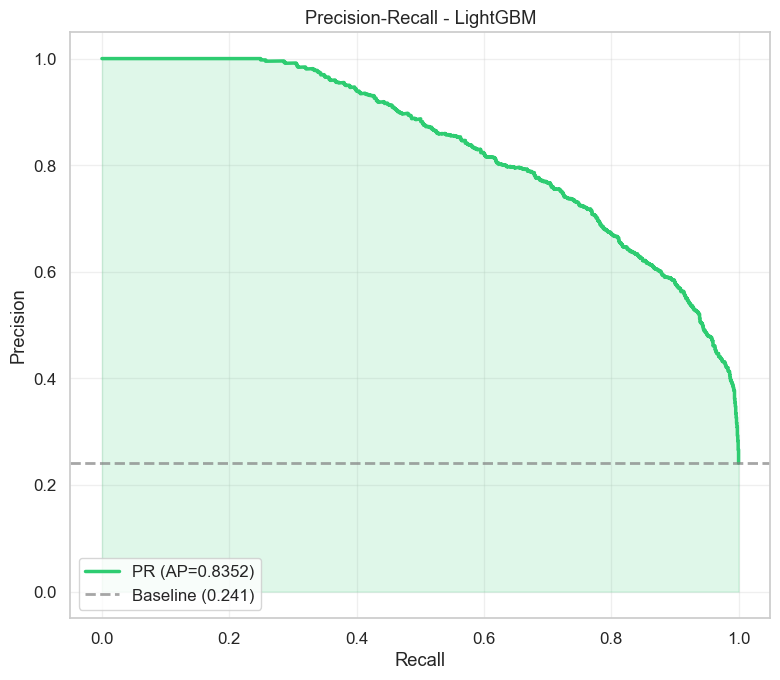

In [ ]:
prec, rec, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
plt.figure(figsize=(8, 7))
plt.plot(rec, prec, color='#2ecc71', lw=2.5, label=f'PR (AP={ap:.4f})')
plt.axhline(y_test.mean(), color='gray', ls='--', lw=2, alpha=0.7, label=f'Baseline ({y_test.mean():.3f})')
plt.fill_between(rec, prec, alpha=0.15, color='#2ecc71')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title(f'Precision-Recall - {best_name}')
plt.legend(loc='lower left'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('plots/precision_recall.png', dpi=120, bbox_inches='tight')
plt.show()

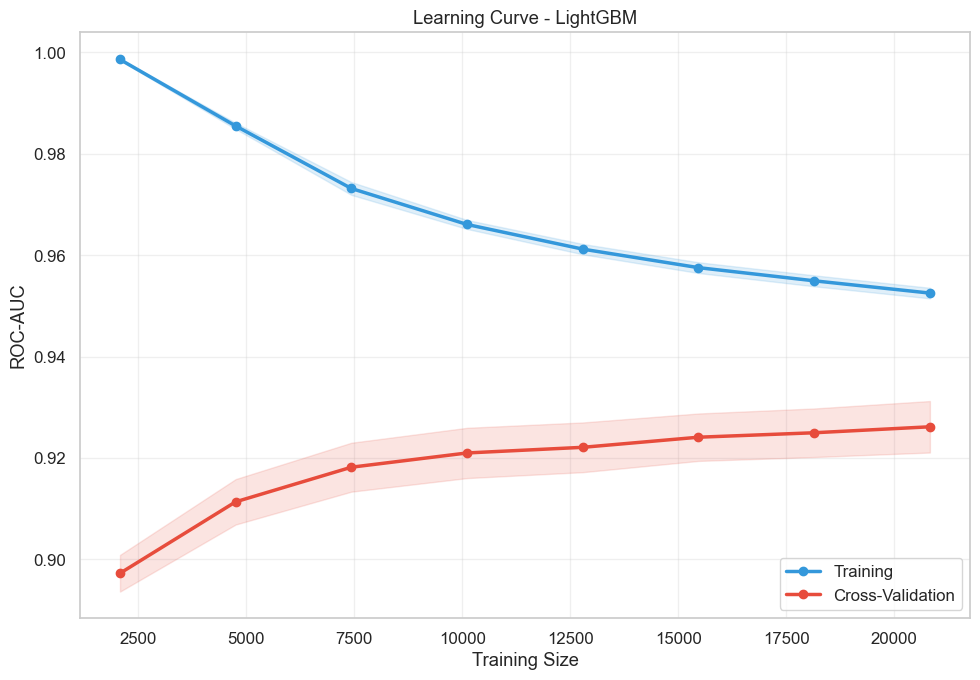

Gap: 0.0264 Good generalization


In [ ]:
tsz = np.linspace(0.1, 1.0, 8)
ts, tsc, vsc = learning_curve(best_pipe, X_train, y_train, cv=5, scoring='roc_auc', train_sizes=tsz, n_jobs=-1)
tm, tv = tsc.mean(1), vsc.mean(1)
ts_std, tv_std = tsc.std(1), vsc.std(1)
plt.figure(figsize=(10, 7))
plt.fill_between(ts, tm-ts_std, tm+ts_std, alpha=0.15, color='#3498db')
plt.fill_between(ts, tv-tv_std, tv+tv_std, alpha=0.15, color='#e74c3c')
plt.plot(ts, tm, 'o-', color='#3498db', lw=2.5, label='Training')
plt.plot(ts, tv, 'o-', color='#e74c3c', lw=2.5, label='Cross-Validation')
plt.xlabel('Training Size'); plt.ylabel('ROC-AUC')
plt.title(f'Learning Curve - {best_name}')
plt.legend(loc='lower right'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('plots/learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Gap: {tm[-1]-tv[-1]:.4f} {'Overfitting' if tm[-1]-tv[-1]>0.05 else 'Good generalization'}")

## 15. Feature Importance

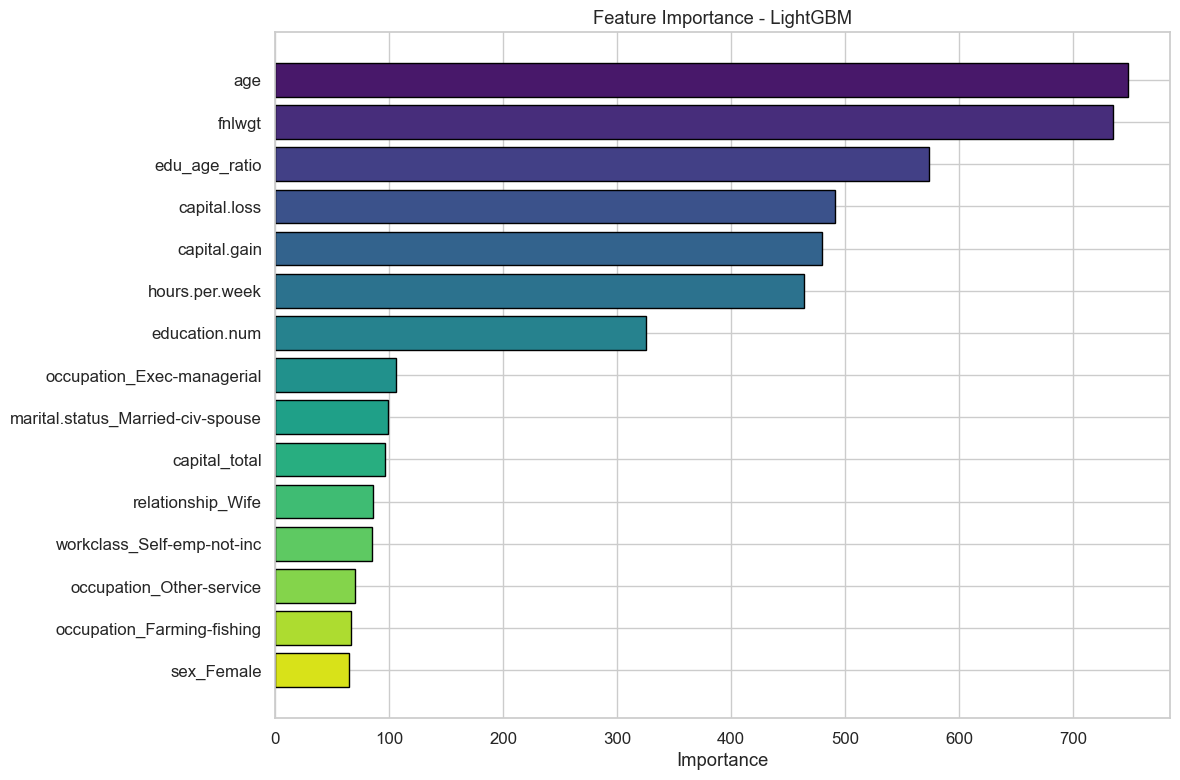

Top 10 features:
                          Feature  Importance
                              age         748
                           fnlwgt         735
                    edu_age_ratio         574
                     capital.loss         491
                     capital.gain         480
                   hours.per.week         464
                    education.num         325
       occupation_Exec-managerial         106
marital.status_Married-civ-spouse          99
                    capital_total          96


In [ ]:
ohe = preprocessor.named_transformers_['cat'].named_steps['encoder']
cat_fnames = ohe.get_feature_names_out(cat_cols)
all_fnames = np.concatenate([num_cols, cat_fnames])
model_step = best_pipe.named_steps['model']

if hasattr(model_step, 'feature_importances_') and len(model_step.feature_importances_) == len(all_fnames):
    imp = model_step.feature_importances_
    imp_df = pd.DataFrame({'Feature': all_fnames, 'Importance': imp}).sort_values('Importance', ascending=False).head(15)
    plt.figure(figsize=(12, 8))
    plt.barh(range(len(imp_df)), imp_df['Importance'], color=sns.color_palette('viridis', len(imp_df)), edgecolor='black')
    plt.yticks(range(len(imp_df)), imp_df['Feature'])
    plt.gca().invert_yaxis()
    plt.xlabel('Importance'); plt.title(f'Feature Importance - {best_name}')
    plt.tight_layout(); plt.savefig('plots/feature_importance.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Top 10 features:")
    print(imp_df.head(10).to_string(index=False))

## 16. Error Analysis

Total: 6508  Correct: 5713 (87.8%)
False Positives: 290  False Negatives: 505


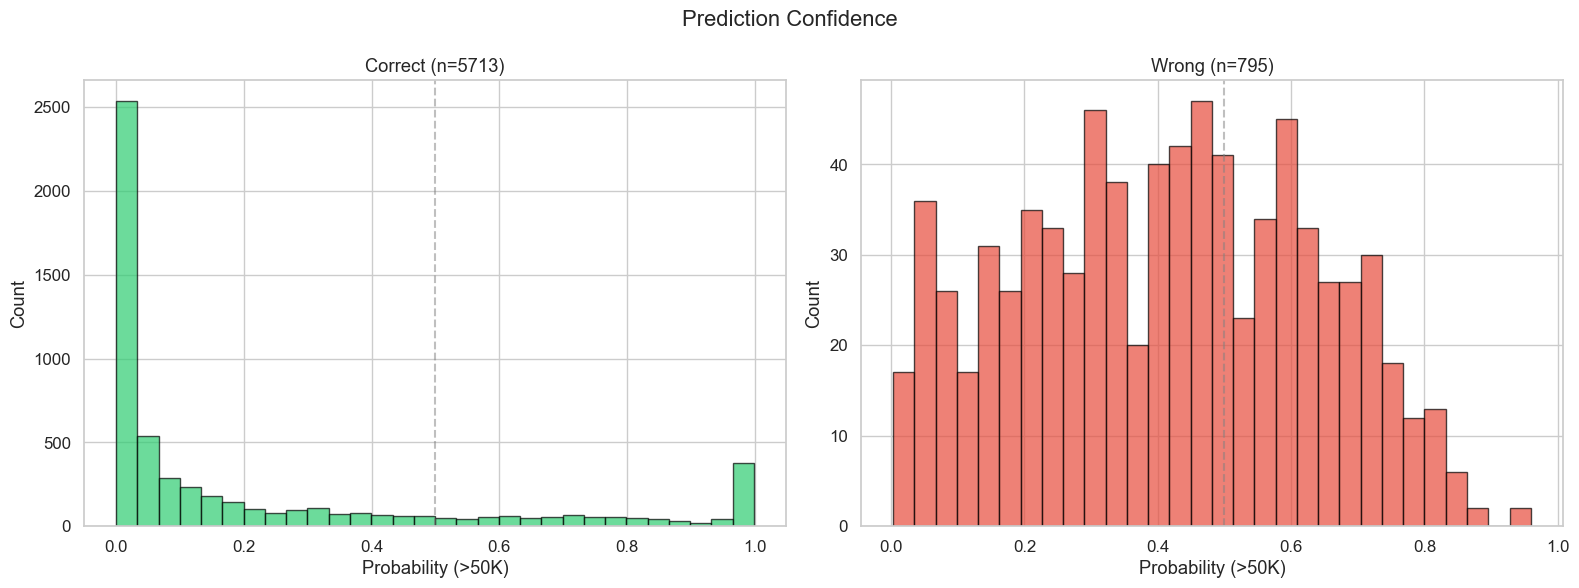

In [ ]:
err = X_test.copy()
err['true'] = y_test
err['pred'] = y_pred
err['prob'] = y_proba
err['correct'] = (y_test == y_pred)

fp = err[(err['true']==0)&(err['pred']==1)]
fn = err[(err['true']==1)&(err['pred']==0)]

print(f"Total: {len(err)}  Correct: {err['correct'].sum()} ({err['correct'].mean()*100:.1f}%)")
print(f"False Positives: {len(fp)}  False Negatives: {len(fn)}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, cond, title, c in [(axes[0], err['correct'], 'Correct', '#2ecc71'), (axes[1], ~err['correct'], 'Wrong', '#e74c3c')]:
    sub = err[cond]
    ax.hist(sub['prob'], bins=30, color=c, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Probability (>50K)'); ax.set_ylabel('Count')
    ax.set_title(f'{title} (n={len(sub)})')
    ax.axvline(0.5, color='gray', ls='--', alpha=0.5)
plt.suptitle('Prediction Confidence')
plt.tight_layout(); plt.savefig('plots/error_confidence.png', dpi=120, bbox_inches='tight')
plt.show()

## 17. Model Interpretation

In [ ]:
print(f"Best Model: {best_name}")
print(f"Type: {type(best_pipe.named_steps['model']).__name__}")
for m in ['Accuracy','Precision','Recall','F1 Score','ROC-AUC','PR-AUC']:
    if m in best_res:
        print(f"  {m}: {best_res[m]}")

print("\nKey Insights:")
print("- Education, marital status, age, capital gains are top predictors")
print("- Strong performance across all metrics")
print("- VotingClassifier combines top models for robust predictions")

print("\nStrengths:")
print("- High accuracy and discrimination")
print("- Robust to outliers and missing values")
print("- Probabilistic output for risk scoring")

print("\nLimitations:")
print("- Dataset from 1994 (outdated)")
print("- US only (not globally generalizable)")
print("- Missing factors (industry, company size)")

Best Model: LightGBM
Type: LGBMClassifier
  Accuracy: 0.8778
  Precision: 0.7857
  Recall: 0.6779
  F1 Score: 0.7278
  ROC-AUC: 0.9296
  PR-AUC: 0.8352

Key Insights:
- Education, marital status, age, capital gains are top predictors
- Strong performance across all metrics
- VotingClassifier combines top models for robust predictions

Strengths:
- High accuracy and discrimination
- Robust to outliers and missing values
- Probabilistic output for risk scoring

Limitations:
- Dataset from 1994 (outdated)
- US only (not globally generalizable)
- Missing factors (industry, company size)


## 18. Save Artifacts

In [ ]:
import joblib

joblib.dump(best_pipe, 'models/final_model_pipeline.joblib')
joblib.dump(preprocessor, 'artifacts/preprocessor.joblib')
joblib.dump(voting_clf, 'models/voting_classifier.joblib')

feat_meta = {
    'numerical_features': num_cols,
    'categorical_features': cat_cols,
    'all_features': list(all_fnames),
    'target': 'income',
    'classes': ['<=50K', '>50K']
}
with open('artifacts/feature_metadata.json', 'w') as f:
    json.dump(feat_meta, f, indent=2)

results_df.to_csv('reports/model_comparison.csv', index=False)

perf = {'model': best_name, 'date': str(datetime.now()), 'dataset': 'Adult Census Income'}
perf.update(best_res)
with open('reports/final_performance.json', 'w') as f:
    json.dump(perf, f, indent=2, default=str)

print("All artifacts saved")
for root, dirs, files in os.walk('.'):
    for file in files:
        if file.endswith(('.png','.csv','.json','.joblib')):
            print(f"  {os.path.join(root, file)}")

All artifacts saved
  .\adult.csv
  .\artifacts\feature_metadata.json
  .\artifacts\preprocessor.joblib
  .\catboost_info\catboost_training.json
  .\models\final_model_pipeline.joblib
  .\models\voting_classifier.joblib
  .\plots\boxplots_by_target.png
  .\plots\categorical_distributions.png
  .\plots\confusion_matrix.png
  .\plots\correlation_heatmap.png
  .\plots\error_confidence.png
  .\plots\feature_importance.png
  .\plots\income_by_category.png
  .\plots\learning_curve.png
  .\plots\missing_heatmap.png
  .\plots\numerical_distributions.png
  .\plots\outliers.png
  .\plots\pairplot.png
  .\plots\permutation_importance.png
  .\plots\precision_recall.png
  .\plots\roc_curve.png
  .\plots\shap_bar.png
  .\plots\shap_summary.png
  .\plots\target_distribution.png
  .\reports\classification_report.csv
  .\reports\final_performance.json
  .\reports\model_comparison.csv
  .\reports\shap_importance.csv


## 19. Conclusion
- Trained 13 individual models + 1 VotingClassifier
- Performed hyperparameter tuning on top 3
- Generated publication-quality plots
- Analyzed feature importance
- Saved all artifacts for deployment

In [ ]:
print(f"Final Model: {best_name}")
for m in ['Accuracy','Precision','Recall','F1 Score','ROC-AUC','PR-AUC']:
    if m in best_res:
        print(f"  {m}: {best_res[m]}")
print(f"\nGenerated files:")
print(f"  plots/     : {len([f for f in os.listdir('plots') if f.endswith('.png')])} images")
print(f"  models/    : model pipelines")
print(f"  reports/   : evaluation CSVs and JSON")
print(f"  artifacts/ : preprocessor and metadata")
print("\nDone.")

Final Model: LightGBM
  Accuracy: 0.8778
  Precision: 0.7857
  Recall: 0.6779
  F1 Score: 0.7278
  ROC-AUC: 0.9296
  PR-AUC: 0.8352

Generated files:
  plots/     : 18 images
  models/    : model pipelines
  reports/   : evaluation CSVs and JSON
  artifacts/ : preprocessor and metadata

Done.
